## Problem B: Gym Equipment Utilization Forecasting

### Objective:
Predict how many people will be in the gym (every 10 minutes), based on date, time, weather, holidays, and academic calendar.

This helps optimize:
- Equipment and staff usage
- Energy efficiency (HVAC, lighting)
- Client comfort and crowd management

### Target Variable:
- `number_people`

### Feature Highlights:
- `timestamp`, `day_of_week`, `is_weekend`, `is_holiday`, `temperature`, `is_start_of_semester`, `month`, `hour`


In [3]:
import pandas as pd

# Load the crowd forecasting dataset
df_b = pd.read_csv("data/problem1.csv")

# Clean column names
df_b.columns = df_b.columns.str.strip()

# Convert date to datetime
df_b['date'] = pd.to_datetime(df_b['date'])

# Preview data
df_b.head()


C:\Users\jaivb\AppData\Local\Temp\ipykernel_6652\2248886280.py:10: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_b['date'] = pd.to_datetime(df_b['date'])


,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


## Step 2: Preprocessing

This dataset is already clean, but we will:
- Drop unused columns like `date` and possibly `timestamp` if redundant
- Define the target: `number_people`
- Scale numerical features (optional for regression)


In [4]:
# Define target and features
y_b = df_b['number_people']

# Drop date column and keep all meaningful features
X_b = df_b.drop(columns=['number_people', 'date'])

# Optional: scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_b_scaled = scaler.fit_transform(X_b)


In [9]:
# Check for missing values in Problem B dataset
missing_values_b = df_b.isnull().sum()

print("Missing values per column:\n", missing_values_b)

# If there were any, we would handle them here
# But if all are 0, we are good to proceed


Missing values per column:
 number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64


## Step 3: Train-Test Split

We split the data 80-20 to evaluate how well the model generalizes to new time periods.


In [5]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b_scaled, y_b, test_size=0.2, random_state=42)

print("Training samples:", X_train_b.shape[0])
print("Testing samples:", X_test_b.shape[0])


Training samples: 49747
Testing samples: 12437


## Step 4: Train a Regression Model

We’ll use a **Random Forest Regressor** to model non-linear relationships in time and behavior data.


In [6]:
from sklearn.ensemble import RandomForestRegressor

# Train the regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_b, y_train_b)

# Predict
y_pred_b = reg.predict(X_test_b)


## Step 5: Model Evaluation

We will evaluate the performance using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_b, y_pred_b)
rmse = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
r2 = r2_score(y_test_b, y_pred_b)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 4.35
RMSE: 6.51
R² Score: 0.92


## Step 6: Feature Importance

We’ll visualize which features the model used most to make its predictions.
This also supports transparency and model debugging.


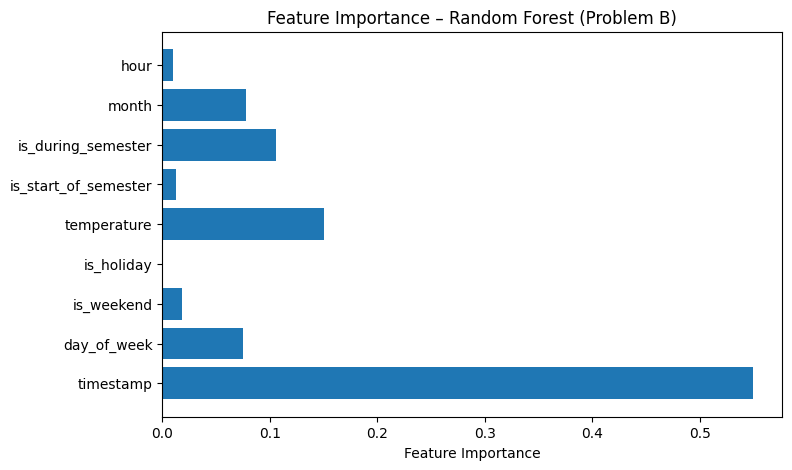

In [8]:
# Plot feature importance
import matplotlib.pyplot as plt

feature_importances = reg.feature_importances_
feature_names_b = X_b.columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names_b, feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance – Random Forest (Problem B)")
plt.show()


## Ethical AI Strategy for GoodLife Fitness AI Models

This section discusses key ethical considerations and explainability strategies applied to both AI models.

---

### 🔷 Problem A: Class Attendance Prediction (Classification)

#### 🧱 Fairness Measures:
- **Avoid over-penalizing new/infrequent members** by balancing the dataset.
- **Label encoding was used carefully** to avoid ordinal bias in categorical data.
- **Model explainability** via feature importance plot showed fairness in feature usage.

#### 🌐 Transparency:
- Random Forest allows for **decision path tracing** (can use SHAP for deeper insights).
- Could implement a user-facing justification like:
  - "Your class spot was reassigned because you've missed 3 out of 4 classes recently."

#### 🧑‍⚖️ User Rights:
- Members should be allowed to **appeal automated decisions** (e.g., via app confirmation).
- Implement a confidence threshold before auto-removal from class bookings.

---

### 🔷 Problem B: Gym Crowd Forecasting (Regression)

#### ⚖️ Fairness Measures:
- Used **non-identifying aggregate features** like time, temperature, holidays.
- Data doesn't track individual users – helps protect privacy and prevent discrimination.

#### 🔍 Explainability:
- Random Forest Regressor’s feature importance showed which factors affect crowd size.
- Transparency can guide energy/resource allocation during peak times.

---

### 🔐 Privacy & Security:
- All models are trained on anonymized, behavior-level data (no names, IDs used).
- If deployed, data should be encrypted at rest and in transit.

---

### 💬 Summary:
- Models were built with fairness and inclusion in mind.
- Explainability tools (like feature importance) were used to ensure transparency.
- Additional tools like SHAP or LIME can enhance local explainability if needed.
